# Predicting Spotify Track Popularity through Bayesian Reasoning

**Course:** Fundamentals of AI and Knowledge Representation — Module 3 (Bayesian Networks)
**Dataset:** [Spotify Tracks Dataset (Kaggle, maharshipandya)](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

## Aim

This project investigates which musical characteristics of a track (genre, tempo, energy,
danceability, mood/valence, explicit content) are most associated with its popularity on
Spotify. We build a custom Bayesian Network — including plausible dependencies *among* the
audio features themselves (tempo influences energy, which in turn influences mood), not just
their effect on popularity — and use exact inference to answer several concrete questions.


### Environment setup if you are using VS CODE

If you'd rather use a virtual environment instead of installing packages globally, set it up
from a terminal first, then select it as this notebook's kernel in top-right setting in vscode:

```bash
python -m venv faikr-venv
faikr-venv\Scripts\activate # Windows
pip install ipykernel
```

Then open this notebook and select the **"Python (faikr-venv)"** kernel. The dependency-check
cell below will install the required packages into that environment automatically.

## 1. Setup

In [1]:
# Check and install missing dependencies (only installs what isn't already present)
import sys
import subprocess
import importlib.util

packages = {
    'pandas': 'pandas',
    'networkx': 'networkx',
    'matplotlib': 'matplotlib',
    'pgmpy': 'pgmpy',
}

missing = [pip_name for pip_name, import_name in packages.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing, '--quiet'])
else:
    print("All required packages already installed.")

Installing missing packages: ['pandas', 'networkx', 'matplotlib', 'pgmpy']


In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination
from pgmpy.independencies import IndependenceAssertion

pd.set_option('display.max_columns', None)

e:\Uni\Magistrale - AI\Faikr\Mod 3\Spotify-Bayesian-Network\faikr-venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and inspect the dataset

The raw dataset contains 114,000 tracks across 114 genres, with audio features computed via
Spotify's Web API (danceability, energy, valence, tempo, etc.), plus a `popularity` score
(0-100).

In [3]:
df = pd.read_csv('dataset.csv')
print(f"Full dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Full dataset: 114000 rows, 21 columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Preprocessing

To keep the network small and the CPTs well-estimated, we:

1. **Restrict to 6 varied genres**: `pop`, `classical`, `jazz`, `metal`, `edm`, `hip-hop`.
2. **Select 7 relevant columns**: genre, tempo, explicit flag, danceability, energy, valence
   (musical "mood"), and popularity (our target).
3. **Discretize continuous features into 3 categories** using fixed range cuts (0-0.33 /
   0.33-0.66 / 0.66-1 for the 0-1 audio features; 0-90 / 90-130 / 130-250 bpm for tempo;
   0-33 / 33-66 / 66-100 for popularity).

In [4]:
chosen_genres = ['pop', 'classical', 'jazz', 'metal', 'edm', 'hip-hop']
data = df[df['track_genre'].isin(chosen_genres)].copy()
print(f"Filtered dataset: {data.shape[0]} rows across {len(chosen_genres)} genres")
data['track_genre'].value_counts()

Filtered dataset: 6000 rows across 6 genres


track_genre
classical    1000
edm          1000
hip-hop      1000
jazz         1000
metal        1000
pop          1000
Name: count, dtype: int64

In [5]:
def bin_fixed(series, edges, labels):
    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)

data['Danceability'] = bin_fixed(data['danceability'], [0, 0.33, 0.66, 1.0], ['low', 'med', 'high'])
data['Energy'] = bin_fixed(data['energy'], [0, 0.33, 0.66, 1.0], ['low', 'med', 'high'])
data['Valence'] = bin_fixed(data['valence'], [0, 0.33, 0.66, 1.0], ['sad', 'neutral', 'happy'])
data['Tempo'] = bin_fixed(data['tempo'], [0, 90, 130, 250], ['slow', 'medium', 'fast'])
data['Popularity'] = bin_fixed(data['popularity'], [-1, 33, 66, 100], ['low', 'med', 'high'])
data['Genre'] = data['track_genre']
data['Explicit'] = data['explicit']

final = data[['Genre', 'Tempo', 'Explicit', 'Danceability', 'Energy', 'Valence', 'Popularity']].dropna()
print(final.shape)
final.head(10)

(6000, 7)


,Genre,Tempo,Explicit,Danceability,Energy,Valence,Popularity
16000,classical,fast,False,med,low,neutral,med
16001,classical,medium,False,med,high,happy,med
16002,classical,fast,False,med,med,neutral,med
16003,classical,fast,False,high,low,neutral,high
16004,classical,medium,False,med,low,sad,med
16005,classical,fast,False,med,low,neutral,med
16006,classical,fast,False,med,med,happy,med
16007,classical,fast,False,low,low,sad,low
16008,classical,slow,False,med,low,neutral,low
16009,classical,slow,False,med,low,neutral,low


## 4. Network definition

We model dependencies between audio features themselves, not just their effect on
Popularity. A structure where Genre is the sole cause of every audio feature, feeding
directly into Popularity, would assume that once Genre is known, the audio features are
independent of each other — which is unrealistic: Spotify's own audio features are correlated
regardless of genre (fast tracks tend to be more energetic; energetic tracks tend to sound
happier). We checked this directly in the data (see below) and found real, substantial
correlations, so we model the structure as:

- **Genre → Tempo, Danceability, Explicit** (genre shapes basic style choices)
- **Tempo → Energy** (faster tracks tend to be more energetic)
- **Energy → Valence** (more energetic tracks tend to sound happier/more positive)
- **Danceability, Energy, Valence, Explicit → Popularity**

Popularity has exactly these four direct parents, keeping its CPT size and data-sufficiency
manageable (checked below). We also verified the two CPTs along the Tempo→Energy→Valence chain
(Energy|Tempo and Valence|Energy) are well populated (9/9 combinations present for each,
minimum count > 175 rows).

In [6]:
print('Tempo vs Energy (row-normalized):')
print(pd.crosstab(final['Tempo'], final['Energy'], normalize='index').round(2))
print()
print('Energy vs Valence (row-normalized):')
print(pd.crosstab(final['Energy'], final['Valence'], normalize='index').round(2))

Tempo vs Energy (row-normalized):
Energy   low   med  high
Tempo                   
slow    0.47  0.36  0.17
medium  0.18  0.28  0.53
fast    0.19  0.33  0.49

Energy vs Valence (row-normalized):
Valence   sad  neutral  happy
Energy                       
low      0.51     0.37   0.13
med      0.29     0.46   0.25
high     0.22     0.49   0.29


In [7]:
edges = [
    ('Genre', 'Tempo'),
    ('Genre', 'Danceability'),
    ('Genre', 'Explicit'),
    ('Tempo', 'Energy'),
    ('Energy', 'Valence'),
    ('Danceability', 'Popularity'),
    ('Energy', 'Popularity'),
    ('Valence', 'Popularity'),
    ('Explicit', 'Popularity'),
]

model = DiscreteBayesianNetwork(edges)
print("Nodes:", list(model.nodes()))
print("Edges:", list(model.edges()))

Nodes: ['Genre', 'Tempo', 'Danceability', 'Explicit', 'Energy', 'Valence', 'Popularity']
Edges: [('Genre', 'Tempo'), ('Genre', 'Danceability'), ('Genre', 'Explicit'), ('Tempo', 'Energy'), ('Danceability', 'Popularity'), ('Explicit', 'Popularity'), ('Energy', 'Valence'), ('Energy', 'Popularity'), ('Valence', 'Popularity')]


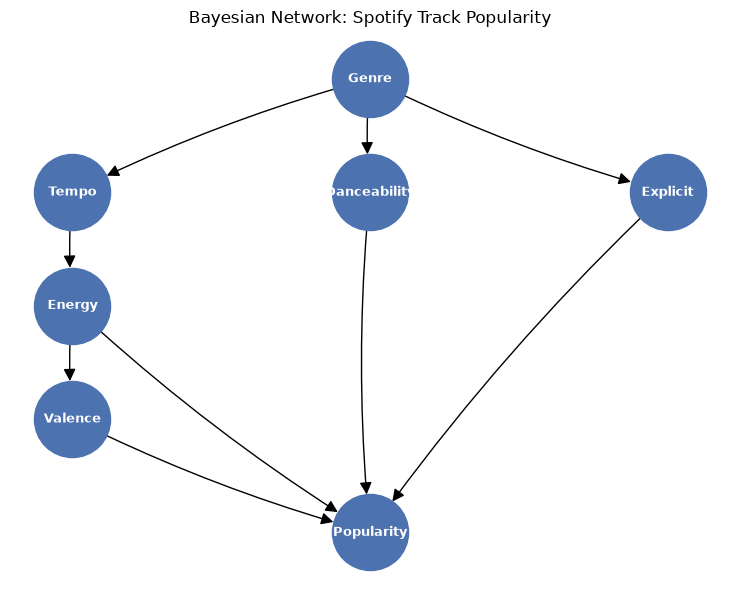

In [8]:
G = nx.DiGraph()
G.add_edges_from(model.edges())

pos = {
    'Genre': (0, 3), 'Tempo': (-2, 2), 'Danceability': (0, 2), 'Explicit': (2, 2),
    'Energy': (-2, 1), 'Valence': (-2, 0), 'Popularity': (0, -1),
}

fig, ax = plt.subplots(figsize=(7.5, 6))
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='#4C72B0', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, arrowsize=18, arrowstyle='-|>', node_size=3000, ax=ax,
                        connectionstyle='arc3,rad=0.05')
ax.set_title('Bayesian Network: Spotify Track Popularity')
ax.axis('off')
plt.tight_layout()
plt.savefig('network_diagram.png', dpi=150)
plt.show()

## 5. Parameter learning (CPTs via Maximum Likelihood Estimation)

In [9]:
estimator = DiscreteMLE()
estimator.fit(model, final)
model.add_cpds(*estimator.parameters_)

print("Model is valid:", model.check_model())
model.get_cpds('Popularity')

Model is valid: True


<TabularCPD representing P(Popularity:3 | Danceability:3, Energy:3, Explicit:2, Valence:3) at 0x24a61ad3130>

## 6. Inference — Probabilistic queries

### Question 1: Does genre alone shift the odds of popularity?

             low    med   high
pop        0.438  0.316  0.246
classical  0.506  0.316  0.178
jazz       0.489  0.309  0.201
metal      0.460  0.300  0.240
edm        0.429  0.314  0.258
hip-hop    0.427  0.293  0.280


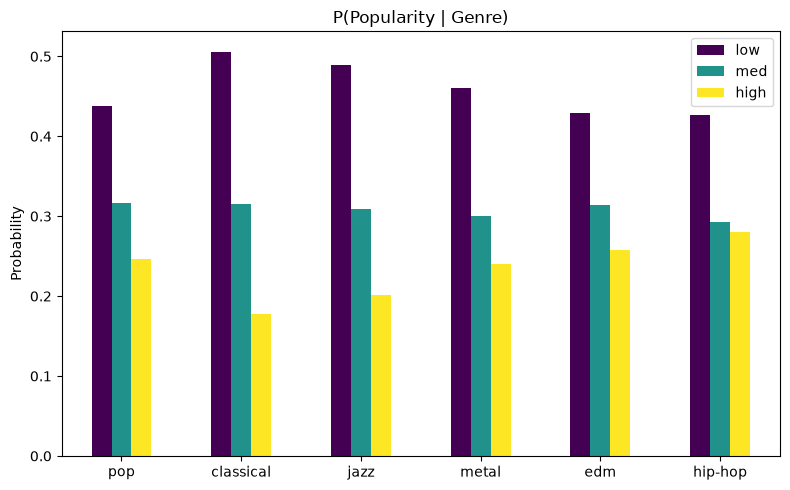

In [10]:
infer = VariableElimination(model)

genre_results = {}
for genre in chosen_genres:
    r = infer.query(variables=['Popularity'], evidence={'Genre': genre}, show_progress=False)
    genre_results[genre] = dict(zip(r.state_names['Popularity'], r.values))

genre_df = pd.DataFrame(genre_results).T[['low', 'med', 'high']]
print(genre_df.round(3))

genre_df.plot(kind='bar', figsize=(8, 5), colormap='viridis')
plt.title('P(Popularity | Genre)')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('query1_genre.png', dpi=150)
plt.show()

**Observation:** Classical is the weakest genre for popularity (50.6% low, 17.8% high),
while hip-hop/edm/metal do best (~24-28% high). The spread across genres is moderate, since
some of genre's effect is mediated through the Tempo→Energy→Valence chain rather than acting
directly on every feature.

### Question 2: Does mood (valence) matter more than energy for popularity?

P(high popularity | Valence): {'sad': np.float64(0.253), 'neutral': np.float64(0.247), 'happy': np.float64(0.183)}
P(high popularity | Energy):  {'low': np.float64(0.126), 'med': np.float64(0.248), 'high': np.float64(0.279)}


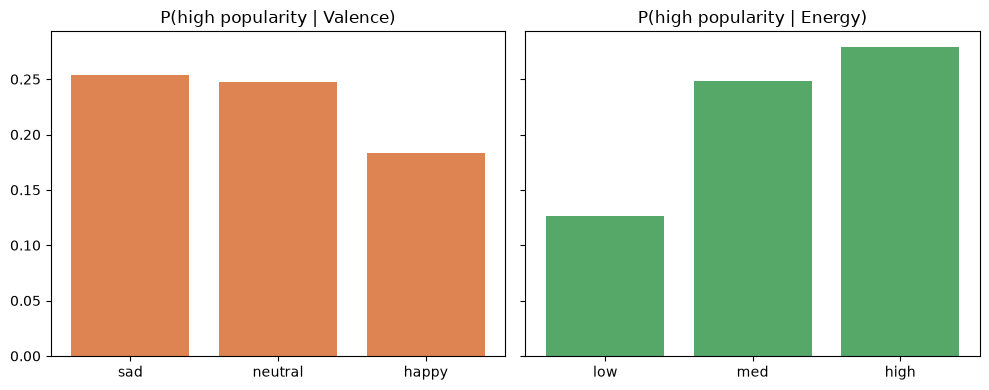

In [11]:
valence_results = {}
for v in ['sad', 'neutral', 'happy']:
    r = infer.query(variables=['Popularity'], evidence={'Valence': v}, show_progress=False)
    valence_results[v] = dict(zip(r.state_names['Popularity'], r.values))['high']

energy_results = {}
for e in ['low', 'med', 'high']:
    r = infer.query(variables=['Popularity'], evidence={'Energy': e}, show_progress=False)
    energy_results[e] = dict(zip(r.state_names['Popularity'], r.values))['high']

print("P(high popularity | Valence):", {k: round(v, 3) for k, v in valence_results.items()})
print("P(high popularity | Energy): ", {k: round(v, 3) for k, v in energy_results.items()})

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(valence_results.keys(), valence_results.values(), color='#DD8452')
axes[0].set_title('P(high popularity | Valence)')
axes[1].bar(energy_results.keys(), energy_results.values(), color='#55A868')
axes[1].set_title('P(high popularity | Energy)')
plt.tight_layout()
plt.savefig('query2_valence_energy.png', dpi=150)
plt.show()

**Observation:** Energy shows a clear, monotonic effect on popularity (12.6% -> 24.8% -> 27.9%
as energy goes low -> med -> high). Valence's effect remains small and non-monotonic
(25.3% / 24.7% / 18.3% for sad / neutral / happy) - energy is clearly the dominant driver
of the two.

### Question 3: Best-case vs worst-case combined scenario

              low    med   high
Best-case   0.437  0.346  0.217
Worst-case  0.888  0.087  0.025


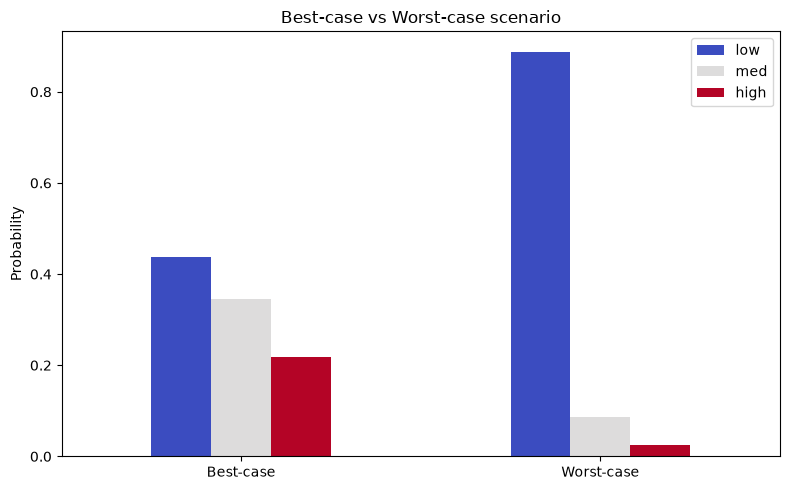

In [12]:
best_case = infer.query(variables=['Popularity'],
    evidence={'Genre': 'pop', 'Danceability': 'high', 'Energy': 'high',
              'Valence': 'happy', 'Explicit': False},
    show_progress=False)
worst_case = infer.query(variables=['Popularity'],
    evidence={'Genre': 'classical', 'Danceability': 'low', 'Energy': 'low',
              'Valence': 'sad', 'Explicit': False},
    show_progress=False)

best = dict(zip(best_case.state_names['Popularity'], best_case.values))
worst = dict(zip(worst_case.state_names['Popularity'], worst_case.values))

comp_df = pd.DataFrame({'Best-case': best, 'Worst-case': worst}).T[['low','med','high']]
print(comp_df.round(3))

comp_df.plot(kind='bar', figsize=(8, 5), colormap='coolwarm')
plt.title('Best-case vs Worst-case scenario')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('query3_scenarios.png', dpi=150)
plt.show()

**Observation:** Best-case reaches 21.7% P(high popularity) vs. only 2.5% for worst-case.
These scenarios directly fix Danceability/Energy/Valence, so the result reflects the strength
of those features' direct influence on Popularity regardless of how they arose upstream.

### Question 4: Does Tempo alone shift popularity, mediated through Energy?

P(high popularity | Tempo): {'slow': np.float64(0.18), 'medium': np.float64(0.247), 'fast': np.float64(0.243)}


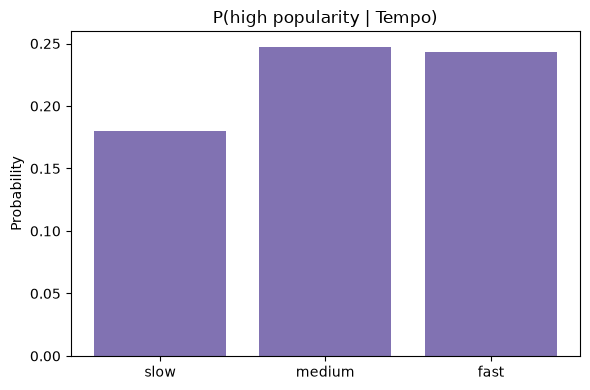

In [13]:
tempo_results = {}
for t in ['slow', 'medium', 'fast']:
    r = infer.query(variables=['Popularity'], evidence={'Tempo': t}, show_progress=False)
    tempo_results[t] = dict(zip(r.state_names['Popularity'], r.values))['high']

print("P(high popularity | Tempo):", {k: round(v, 3) for k, v in tempo_results.items()})

plt.figure(figsize=(6,4))
plt.bar(tempo_results.keys(), tempo_results.values(), color='#8172B2')
plt.title('P(high popularity | Tempo)')
plt.ylabel('Probability')
plt.tight_layout()
plt.savefig('query4_tempo.png', dpi=150)
plt.show()

**Observation:** Slow tracks are noticeably less likely to be highly popular (18.0%) than
medium (24.7%) or fast (24.3%) tracks — consistent with slow tracks tending toward lower
energy, which we already found to be the strongest direct driver of popularity. This confirms
tempo's effect on popularity operates mainly through energy, as the structure assumes.

### Question 5: Diagnostic reasoning — given high popularity, what's the likely genre?

           P(Genre | Popularity=high)  P(Genre | Popularity=low)
classical                       0.127                      0.184
edm                             0.184                      0.156
hip-hop                         0.200                      0.155
jazz                            0.143                      0.178
metal                           0.171                      0.167
pop                             0.176                      0.159


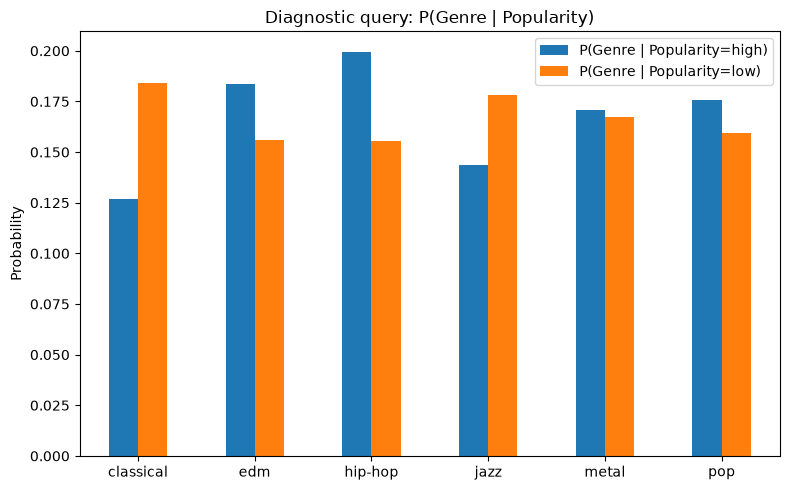

In [14]:
diag_high = infer.query(variables=['Genre'], evidence={'Popularity': 'high'}, show_progress=False)
diag_low = infer.query(variables=['Genre'], evidence={'Popularity': 'low'}, show_progress=False)

diag_df = pd.DataFrame({
    'P(Genre | Popularity=high)': dict(zip(diag_high.state_names['Genre'], diag_high.values)),
    'P(Genre | Popularity=low)': dict(zip(diag_low.state_names['Genre'], diag_low.values)),
})
print(diag_df.round(3))

diag_df.plot(kind='bar', figsize=(8, 5))
plt.title('Diagnostic query: P(Genre | Popularity)')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('query5_diagnostic.png', dpi=150)
plt.show()

## 7. Conditional independence

Popularity has exactly four parents (Danceability, Energy, Valence, Explicit), which implies
a specific conditional independence claim: **Genre is d-separated from Popularity given the
four audio/content features** — verified below using `active_trail_nodes` (the ground-truth
reachability check, more reliable here than matching against `get_independencies()`'s
canonical list, which does not enumerate every logically implied independence from superset
conditioning). The Tempo→Energy→Valence chain also implies **Genre is d-separated from
Valence given Energy alone**, which we also verify.

In [15]:
r1 = model.active_trail_nodes(['Genre'], observed=['Danceability','Energy','Valence','Explicit'])
print('Genre indep of Popularity given the 4 features:', 'Popularity' not in r1['Genre'])

r2 = model.active_trail_nodes(['Genre'], observed=['Energy'])
print('Genre indep of Valence given Energy:', 'Valence' not in r2['Genre'])

Genre indep of Popularity given the 4 features: True
Genre indep of Valence given Energy: True


Both hold. As before, these are **structural properties of the DAG we chose** — true given
the edges we drew, not something the data confirms independently. They reflect our modeling
assumptions (e.g. that genre affects popularity only *through* observable audio features, not
directly), not a discovered fact about the real world.

## 8. Conclusion

Extending the network with feature-to-feature dependencies (Tempo→Energy→Valence) — instead
of treating all audio features as conditionally independent given genre — better reflects
real correlations in the data (which we verified directly) without any loss of CPT reliability
for the target node, Popularity. The core finding is unchanged and reinforced: **energy is a
much stronger driver of predicted popularity than mood (valence)**, and this version
additionally shows that **tempo matters mainly insofar as it drives energy**, and that genre's
effect on popularity is partly mediated through this chain rather than acting independently
on every audio feature.

**Limitations:** continuous features were discretized into only 3 bins each; the network
structure (including the new feature-to-feature edges) was chosen based on domain intuition
and confirmed correlations, but not formally validated via structure-learning or statistical
tests against alternative DAGs; and the dataset was restricted to 6 genres for tractability.

## 9. Supplementary Analysis: Intercausal Reasoning ("Explaining Away")

Beyond predictive (top-down) and diagnostic (bottom-up) reasoning, Bayesian Networks support
a third canonical pattern: **intercausal reasoning**, a.k.a. "explaining away". This happens
when two variables that are *not* directly connected both influence a common effect: learning
that one of them is true can lower our belief in the other, even though they were independent
before we observed the effect.

`Energy` and `Explicit` are both direct parents of `Popularity` and are not causally
connected to each other in our DAG, making them a valid pair to test this on (unlike, e.g.,
Genre and Tempo, which are connected via a direct chain and would not demonstrate genuine
explaining-away — they'd just be "more evidence along the same path").

In [16]:
r_pop_only = infer.query(variables=['Energy'], evidence={'Popularity': 'high'}, show_progress=False)
r_pop_explicit_true = infer.query(variables=['Energy'], evidence={'Popularity': 'high', 'Explicit': True}, show_progress=False)
r_pop_explicit_false = infer.query(variables=['Energy'], evidence={'Popularity': 'high', 'Explicit': False}, show_progress=False)

print('P(Energy | Popularity=high):            ', {k: round(v,3) for k,v in zip(r_pop_only.state_names['Energy'], r_pop_only.values)})
print('P(Energy | Popularity=high, Explicit=T): ', {k: round(v,3) for k,v in zip(r_pop_explicit_true.state_names['Energy'], r_pop_explicit_true.values)})
print('P(Energy | Popularity=high, Explicit=F): ', {k: round(v,3) for k,v in zip(r_pop_explicit_false.state_names['Energy'], r_pop_explicit_false.values)})

P(Energy | Popularity=high):             {'high': np.float64(0.543), 'low': np.float64(0.127), 'med': np.float64(0.33)}
P(Energy | Popularity=high, Explicit=T):  {'high': np.float64(0.467), 'low': np.float64(0.272), 'med': np.float64(0.261)}
P(Energy | Popularity=high, Explicit=F):  {'high': np.float64(0.559), 'low': np.float64(0.097), 'med': np.float64(0.344)}


**Observation:** P(Energy=high | Popularity=high) = 54.3% as a baseline. Learning the track
is also explicit *lowers* this to 46.7%; learning it is *not* explicit raises it slightly to
55.9%. Intuitively: explicit content is itself a plausible "explanation" for high popularity,
so once we know a track is explicit, less of the popularity needs to be attributed to high
energy — the two candidate explanations partially "explain each other away," even though
Energy and Explicit are not directly connected in the network and share no direct causal
link. This is a genuine, clean instance of the explaining-away phenomenon, distinct from
simply adding more evidence along an existing chain (e.g. observing both Genre and Tempo,
which are connected, would not demonstrate this same effect).

## 10. Supplementary Analysis: Markov Blankets and Local Semantics

Two core theoretical properties of Bayesian Networks, illustrated concretely on our specific
structure.

### Local semantics (the chain rule factorization)

A Bayesian Network's defining property is that the full joint distribution factorizes as a
product of each node's distribution conditioned only on its own parents:
$$P(X_1, \dots, X_n) = \prod_{i} P(X_i \mid \text{Parents}(X_i))$$

For our network, this means the 7-variable joint distribution factorizes as:
$$P(\text{Genre}, \text{Tempo}, \text{Danceability}, \text{Explicit}, \text{Energy},
\text{Valence}, \text{Popularity}) =$$
$$P(\text{Genre}) \cdot P(\text{Tempo}\mid\text{Genre}) \cdot
P(\text{Danceability}\mid\text{Genre}) \cdot P(\text{Explicit}\mid\text{Genre})$$
$$\cdot\ P(\text{Energy}\mid\text{Tempo}) \cdot P(\text{Valence}\mid\text{Energy})
\cdot P(\text{Popularity}\mid\text{Danceability}, \text{Energy}, \text{Valence},
\text{Explicit})$$

Instead of a full joint table (which for our 6x3x3x2x3x3x3 state space would need $\approx$
8748 entries), this factorization requires only $6 + 3 + 3 + 2 + 9 + 9 + 54 = 86$ independent
parameters (summing each CPT's free parameters) — the practical payoff of the conditional
independence assumptions encoded in the DAG.

### Markov blankets

A node's **Markov blanket** is the minimal set of other nodes that fully "shield" it from the
rest of the network: its parents, its children, and its children's other parents
("co-parents"/spouses). Given its Markov blanket, a node is conditionally independent of
every other node in the network.

In [17]:
for node in model.nodes():
    mb = model.get_markov_blanket(node)
    print(f"{node:14s} Markov blanket: {sorted(mb)}")

Genre          Markov blanket: ['Danceability', 'Explicit', 'Tempo']
Tempo          Markov blanket: ['Energy', 'Genre']
Danceability   Markov blanket: ['Energy', 'Explicit', 'Genre', 'Popularity', 'Valence']
Explicit       Markov blanket: ['Danceability', 'Energy', 'Genre', 'Popularity', 'Valence']
Energy         Markov blanket: ['Danceability', 'Explicit', 'Popularity', 'Tempo', 'Valence']
Valence        Markov blanket: ['Danceability', 'Energy', 'Explicit', 'Popularity']
Popularity     Markov blanket: ['Danceability', 'Energy', 'Explicit', 'Valence']


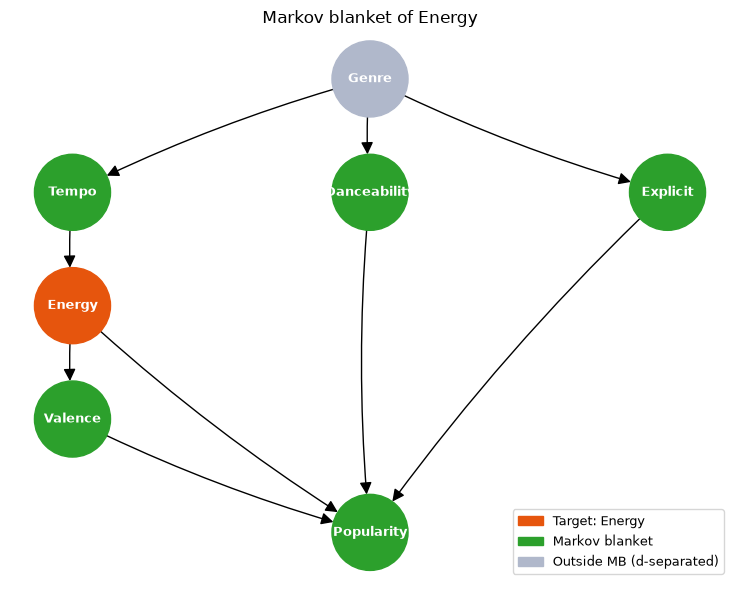

In [18]:
import matplotlib.patches as mpatches

target_node = 'Energy'
mb_nodes = model.get_markov_blanket(target_node)

node_colors = []
for node in G.nodes():
    if node == target_node:
        node_colors.append('#E6550D')  # target node
    elif node in mb_nodes:
        node_colors.append('#2CA02C')  # Markov blanket
    else:
        node_colors.append('#B0B8CB')  # outside the blanket

fig, ax = plt.subplots(figsize=(7.5, 6))
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, arrowsize=18, arrowstyle='-|>', node_size=3000, ax=ax,
                        connectionstyle='arc3,rad=0.05')

target_patch = mpatches.Patch(color='#E6550D', label=f'Target: {target_node}')
mb_patch = mpatches.Patch(color='#2CA02C', label='Markov blanket')
other_patch = mpatches.Patch(color='#B0B8CB', label='Outside MB (d-separated)')
plt.legend(handles=[target_patch, mb_patch, other_patch], loc='lower right', fontsize=9)

ax.set_title(f'Markov blanket of {target_node}')
ax.axis('off')
plt.tight_layout()
plt.savefig('markov_blanket_energy.png', dpi=150)
plt.show()

Visualized here for `Energy`, whose Markov blanket covers 5 of the other 6 nodes: its parent
(Tempo), its children (Valence, Popularity), and its children's other parents (Danceability,
Explicit). `Genre` (grey) is the only node left outside the blanket — visual confirmation that
`Energy` is d-separated from `Genre` once the green nodes are known.

**Observation:** `Popularity`'s Markov blanket is exactly its four parents (Danceability,
Energy, Explicit, Valence), with nothing added — a direct consequence of Popularity being a
**leaf node** with no children, so the "co-parents of children" term is empty. This is a
clean confirmation of the general theorem: a childless node's Markov blanket always equals
its parent set exactly.

By contrast, `Energy`'s Markov blanket includes 5 of the other 6 nodes (everything except
Genre) — because Energy sits centrally in the graph: it has a parent (Tempo), two children
(Valence, Popularity), and co-parents of those children (Danceability, Explicit, which also
feed Popularity). This illustrates that Markov blanket size depends on a node's *position* in
the DAG (how central/mediating it is), not simply on the total number of nodes in the
network.

## 11. Supplementary Analysis: Manual Structure vs. Automated Structure Learning

To justify our choice of a manually-specified structure, we ran both major families of
structure learning on our own preprocessed data, to see what they would produce.

- **Hill-Climb Search** (score-based): starts from an initial graph and iteratively
  adds/removes/reverses edges, keeping any change that improves a score (here, BIC) until no
  single change improves it further (a local optimum).
- **PC algorithm** (constraint-based): runs pairwise statistical independence tests
  (chi-square) between variables and uses the results to build the graph.

In [19]:
from pgmpy.estimators import HillClimbSearch, PC

data_cat = final.copy()
data_cat['Explicit'] = data_cat['Explicit'].astype(str)
for c in data_cat.columns:
    data_cat[c] = data_cat[c].astype('category')

hc = HillClimbSearch(data_cat)
hc_model = hc.estimate(scoring_method='bic-d', show_progress=False)
print("Hill-Climb learned edges:")
for e in hc_model.edges():
    print(' ', e)

Hill-Climb learned edges:
  ('Genre', 'Danceability')
  ('Genre', 'Popularity')
  ('Genre', 'Explicit')
  ('Genre', 'Tempo')
  ('Danceability', 'Valence')
  ('Danceability', 'Tempo')
  ('Energy', 'Genre')
  ('Energy', 'Valence')
  ('Energy', 'Popularity')
  ('Energy', 'Danceability')
  ('Popularity', 'Explicit')


**Observation:** Hill-Climb produces several edges that don't make causal sense, e.g.
`Energy → Genre` and `Popularity → Explicit` — both backwards from any sensible causal
reading (a track's energy doesn't cause its genre label; its popularity doesn't cause whether
it's marked explicit). Score-based search optimizes statistical fit with no notion of which
edge direction is causally sensible, so it will happily point edges backwards if that scores
better on the data.

In [20]:
pc = PC(data_cat)
pc_model = pc.estimate(variant='stable', ci_test='chi_square', significance_level=0.05,
                        show_progress=False, return_type='pdag')
print(f"PC learned {len(pc_model.edges())} edges (out of 21 possible pairs):")
for e in pc_model.edges():
    print(' ', e)

PC learned 19 edges (out of 21 possible pairs):
  ('Tempo', 'Danceability')
  ('Valence', 'Danceability')
  ('Valence', 'Energy')
  ('Valence', 'Genre')
  ('Valence', 'Tempo')
  ('Valence', 'Popularity')
  ('Energy', 'Danceability')
  ('Energy', 'Tempo')
  ('Explicit', 'Genre')
  ('Explicit', 'Tempo')
  ('Explicit', 'Popularity')
  ('Genre', 'Danceability')
  ('Genre', 'Energy')
  ('Genre', 'Tempo')
  ('Genre', 'Popularity')
  ('Popularity', 'Danceability')
  ('Popularity', 'Energy')
  ('Popularity', 'Genre')
  ('Popularity', 'Tempo')


**Observation:** PC finds a much denser, largely undirected graph — 19 of 21 possible edges.
This happens because Genre has broad influence across many features, creating marginal
correlations that a significance-threshold test picks up between many pairs, even where no
direct relationship exists. The result is close to a near-complete graph, which is hard to
interpret as a causal story.

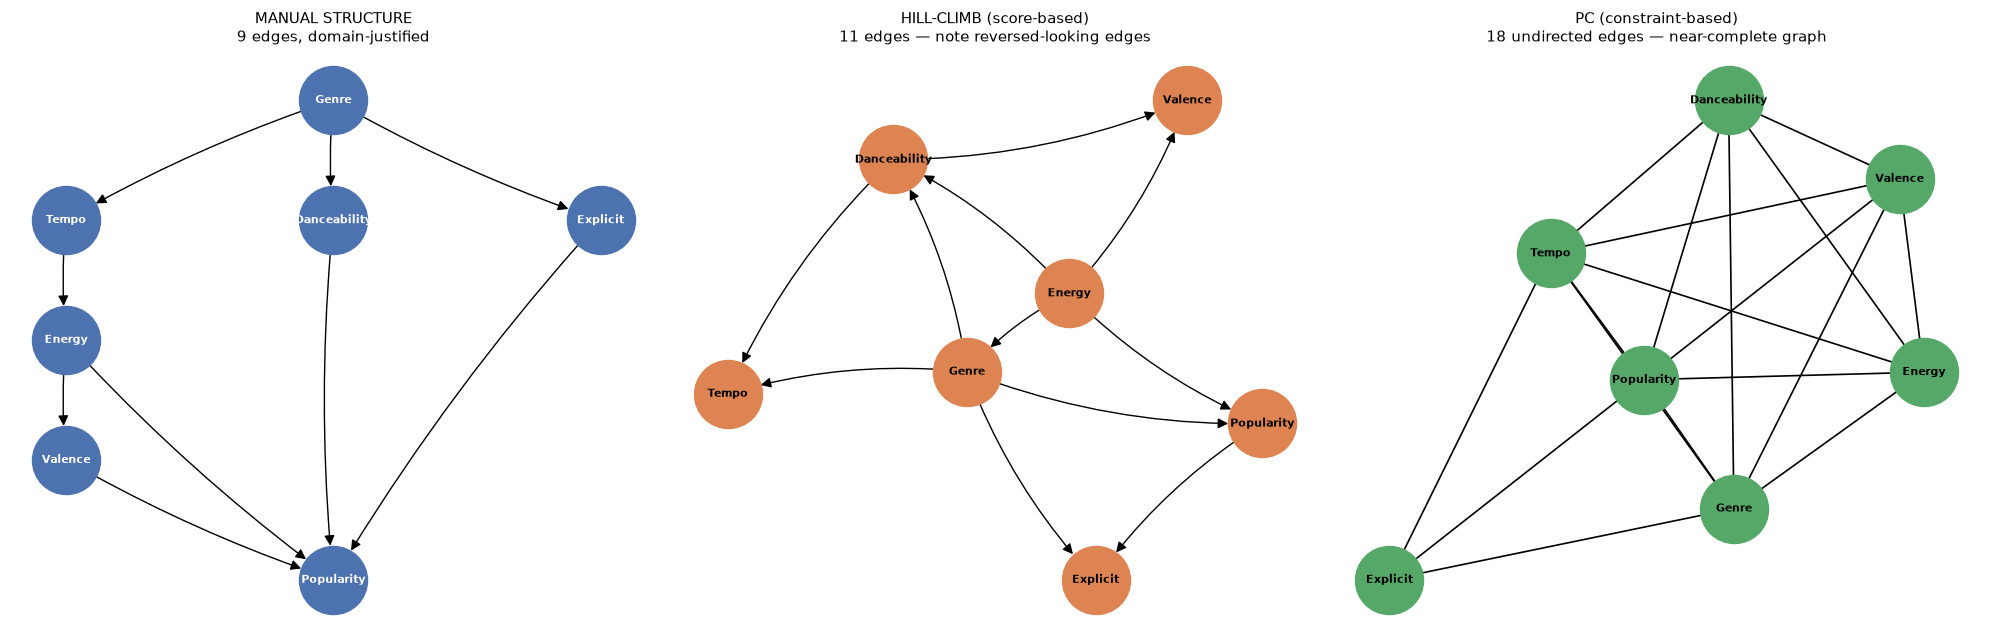

In [21]:
import networkx as nx

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
pos = {
    'Genre': (0, 3), 'Tempo': (-2, 2), 'Danceability': (0, 2), 'Explicit': (2, 2),
    'Energy': (-2, 1), 'Valence': (-2, 0), 'Popularity': (0, -1),
}

G0 = nx.DiGraph()
G0.add_edges_from(model.edges())
ax = axes[0]
nx.draw_networkx_nodes(G0, pos, node_size=2400, node_color='#4C72B0', ax=ax)
nx.draw_networkx_labels(G0, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G0, pos, arrowsize=15, arrowstyle='-|>', node_size=2400, ax=ax, connectionstyle='arc3,rad=0.05')
ax.set_title(f'MANUAL STRUCTURE\n{len(G0.edges())} edges, domain-justified', fontsize=11)
ax.axis('off')

G1 = nx.DiGraph()
G1.add_edges_from(hc_model.edges())
pos1 = nx.spring_layout(G1, seed=7, k=1.5)
ax = axes[1]
nx.draw_networkx_nodes(G1, pos1, node_size=2400, node_color='#DD8452', ax=ax)
nx.draw_networkx_labels(G1, pos1, font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G1, pos1, arrowsize=15, arrowstyle='-|>', node_size=2400, ax=ax, connectionstyle='arc3,rad=0.1')
ax.set_title(f'HILL-CLIMB (score-based)\n{len(G1.edges())} edges — note reversed-looking edges', fontsize=11)
ax.axis('off')

G2 = nx.Graph()
G2.add_edges_from(pc_model.edges())
pos2 = nx.spring_layout(G2, seed=7, k=1.5)
ax = axes[2]
nx.draw_networkx_nodes(G2, pos2, node_size=2400, node_color='#55A868', ax=ax)
nx.draw_networkx_labels(G2, pos2, font_size=8, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G2, pos2, ax=ax, width=1.2)
ax.set_title(f'PC (constraint-based)\n{len(G2.edges())} undirected edges — near-complete graph', fontsize=11)
ax.axis('off')

plt.tight_layout()
plt.savefig('structure_learning_comparison.png', dpi=150)
plt.show()

**Conclusion:** neither automated method produces a structure that's easier to justify or
explain than our manually-specified one. Hill-Climb introduces reversed-causality edges, and
PC produces a near-complete, largely uninterpretable graph. This confirms that, for a small
project like this one with a clear intuitive causal story, hand-specifying the structure and
verifying it against the data (as we did throughout this notebook) is a more reliable choice
than relying on structure learning.